In [1]:
####################################
#ENVIRONMENT SETUP

In [2]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import pickle 

#file classes
import glob

#loading bar
from tqdm import tqdm

#datetime 
from datetime import datetime

In [3]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [4]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "InitialFigures")
dataType = "SurfaceVariableAnimations"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/MPAS_Model_Data/InitialFigures



In [5]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import FigurePlotting_Class

In [6]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class,DataOperator_Class

In [7]:
#Setup

# Region = "TRACER"; Case = "WET"; spinup_hours = "0"
# Region = "TRACER"; Case = "DIURNAL"; spinup_hours = "-5"

# Region = "PRECIP"; Case = "WET"; spinup_hours = "12"
# Region = "PRECIP"; Case = "DIURNAL"; spinup_hours = "12"

Region = "Hawaii"; Case = "TRADES"; spinup_hours = "0"

In [8]:
#Load Model Directory Class
RunType = (Region,Case,"NSSL",spinup_hours)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

RunType = (Region,Case,"TEMPO",spinup_hours)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/TRADES/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-08-08_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/TRADES/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-08-08_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         Hawaii
 Case:           TRADES
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-08-08 to 2022-08-10
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:193
 # Diag Files:   193
 # Time Steps:   193
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/TRADES/MPAS-Model_NSSL/model_run_spinup0hrs
 Static File:    Hawaii_regional2

In [9]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [10]:
###############
#JOB ARRAY SETUP

In [11]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_JobArray import JobArray_Class

In [12]:
#JOB ARRAY SETUP
UsingJobArray=True

def GetNumJobs():
    num_jobs=20
    return num_jobs

num_jobs = GetNumJobs()
JobArray = JobArray_Class(total_elements=ModelData_NSSL.Ntime, num_jobs=num_jobs, UsingJobArray=UsingJobArray)
start_job = JobArray.start_job; end_job = JobArray.end_job

def GetNumElements():
    num_elements = np.arange(ModelData_NSSL.Ntime)[start_job:end_job].tolist()
    return num_elements
num_elements = GetNumElements()

Running timesteps from 0:9 



In [13]:
###############
#FUNCTIONS

In [14]:
# def GetVariableOutputFile(varName, t, ModelData, outputPlottingDirectory):
#     folderName = f"{ModelData.region}_{ModelData.case}_{ModelData.mpType}/{varName}"
#     timeString = ModelData.timeStrings[t]
#     fileName = f"{varName}_{timeString}.png"
#     filePath = DirectoryManager.GetOutputFile(outputPlottingDirectory, folderName, fileName)
#     return filePath
    
def BuildVariableDictionary(ModelData, varNames, dataSubset,dataSubset_diag,dataSubset_static,
                            lat,lon,climDictionary):
    variableDictionary = {}
    for varName in varNames:
        # print(f"Adding {varName}")

        # # Getting Output File
        # outputFilePath = GetVariableOutputFile(varName, t, ModelData, outputPlottingDirectory)
        
        # Handle addition of two variables
        if '+' in varName:
            var1, var2 = varName.split('+')
            var1 = var1.strip()
            var2 = var2.strip()
            
            subset1 = DataOperator_Class.GetData_Variable(ModelData, dataSubset,
                                                          dataSubset_diag,dataSubset_static,var1)
            subset2 = DataOperator_Class.GetData_Variable(ModelData, dataSubset,
                                                          dataSubset_diag,dataSubset_static,var2)
            variableSubset = subset1 + subset2

            # Combine CLims from both variables
            if (var1 in climDictionary) and (var2 in climDictionary):
                vmin = min(climDictionary[var1][0], climDictionary[var2][0])
                vmax = max(climDictionary[var1][1], climDictionary[var2][1])
                clim = (vmin, vmax)
        
        else:
            variableSubset = DataOperator_Class.GetData_Variable(ModelData, 
                                                                 dataSubset,dataSubset_diag,dataSubset_static,varName)
            clim = climDictionary[varName]

        #Setting up Units and Multiplier
        units = ModelData.GetUnits_Specific(varName).replace(" ", r"\ ")
        if varName in ["qv","qc","qi","qr","q2","qfx"]:
            multiplier = 1e3
            units = units.replace('kg', 'g', 1)
        else:
            multiplier = 1

        #Setting up center_colorbar
        if varName in ['u10','v10','w','uReconstructZonal','uReconstructMeridional']:
            center_colorbar=True
        elif varName in ['hfx','lh']:#,'qfx']:
            center_colorbar=True
        else:
            center_colorbar=False
        
        # Store in dictionary
        variableDictionary[varName] = {
            "data": variableSubset,
            "lat": lat,
            "lon": lon,
            "units": units,
            "multiplier": multiplier,
            # "outputFilePath": outputFilePath,
            "clim": clim,
            "center_colorbar": center_colorbar
        }
        
    return variableDictionary

In [15]:
def GetCLims_Average(ModelData, varNames, method="mean",
                     lower_pct=5, upper_pct=95):
    """
    Compute average or percentile-based (vmin, vmax) across all timesteps.
    Also stores the full list of per-timestep min/max values.
    Returns:
        climDictionary (summary dict[varName] = (vmin, vmax))
        full_climDictionary (detailed dict[varName] = {"vmins": [...], "vmaxs": [...]})
    """
    import numpy as np
    from tqdm import tqdm

    if isinstance(varNames, str):
        varNames = [varNames]

    # store lists of per-timestep values
    full_climDictionary = {v: {"vmins": [], "vmaxs": []} for v in varNames}

    for t in tqdm(range(len(ModelData.fileList)), desc="Processing timesteps"):
        data = ModelData.GetDataTimestep(t, printout=False)
        data_diag = ModelData.GetDataTimestep_diag(t, printout=False)

        for varName in varNames:
            variableSubset, _, _ = DataOperator_Class.GetVariable_Subset(
                ModelData, data, data_diag, ModelData.staticData, varName
            )
            
            vmin = np.nanmin(variableSubset)
            vmax = np.nanmax(variableSubset)
            full_climDictionary[varName]["vmins"].append(vmin)
            full_climDictionary[varName]["vmaxs"].append(vmax)

        data.close()
        data_diag.close()

    # summarize
    climDictionary = {}
    for varName in varNames:
        vmins = np.array(full_climDictionary[varName]["vmins"])
        vmaxs = np.array(full_climDictionary[varName]["vmaxs"])

        if method == "mean":
            climDictionary[varName] = (np.mean(vmins), np.mean(vmaxs))
        elif method == "percentile":
            climDictionary[varName] = (
                np.percentile(vmins, lower_pct),
                np.percentile(vmaxs, upper_pct)
            )
        elif method == "max":
            climDictionary[varName] = (
                np.nanmin(vmins),
                np.nanmax(vmaxs)
            )
        else:
            raise ValueError("method must be 'mean' or 'percentile'")

    return climDictionary, full_climDictionary

def LoadOrCreateCLims(ModelData, varNames,
                              method="mean"):
    """
    Loads both the summarized and full clim dictionaries if they exist.
    Otherwise computes, saves, and returns them.
    Returns:
        climDictionary, full_climDictionary
    """
    import pickle
    import os

    
    fileName=f"climDictionary_{ModelData.region}_{ModelData.case}_{ModelData.mpType}.pkl"
    filePath = os.path.join(outputDirectory,fileName)

    if os.path.exists(filePath):
        print(f"Loading existing clim dictionaries from {filePath}")
        with open(filePath, "rb") as f:
            data = pickle.load(f)

        # backward compatibility: handle old format
        if isinstance(data, tuple):
            climDictionary, full_climDictionary = data
        else:
            climDictionary = data.get("climDictionary", {})
            full_climDictionary = data.get("full_climDictionary", {})
    else:
        print(f"File {filePath} not found. Computing new clim dictionaries.")
        climDictionary, full_climDictionary = GetCLims_Average(
            ModelData, varNames, method=method
        )
        with open(filePath, "wb") as f:
            pickle.dump(
                {"climDictionary": climDictionary,
                 "full_climDictionary": full_climDictionary},
                f
            )
        print(f"Saved clim dictionaries to {filePath}")

    return climDictionary, full_climDictionary

In [16]:
#PlotVariable_with_Borders()

# Preload map features once
COAST = cfeature.COASTLINE.with_scale("50m")
BORDERS = cfeature.BORDERS.with_scale("50m")
STATES = cfeature.STATES.with_scale("50m")
LAND = cfeature.LAND.with_scale("50m")
LAKES = cfeature.LAKES.with_scale("50m")

# def CreateAxis():
#     # Create figure
#     fig, axis = plt.subplots(
#         subplot_kw={'projection': ccrs.PlateCarree()},
#         figsize=(9, 5))
#     return fig,axis

def CreateAxis():
    """
    Creates a 1×2 subplot using GridSpec with PlateCarree projection.
    Returns the figure and axes.
    """
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 1], wspace=0.3)

    ax0 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
    axes = [ax0, ax1]
    return fig, axes

def PlotVariable_with_Borders(axis, 
                              variable, varName, lat,lon, multiplier, 
                              clim=(None,None), norm=None, cmap="viridis",
                              title=None, units=None,
                              center_colorbar=False):
    """
    Plot a uxarray or xarray variable on a map with coastlines, borders, and states,
    using Matplotlib (static PNG output). Works headlessly — no Selenium needed.
    """

    num_levels=19
    if clim != (None,None):
        levels = multiplier*np.linspace(clim[0],clim[1],num_levels)
    else:
        levels=num_levels

    # if center_colorbar==True:
    #     cmap = "RdBu_r"
    #     vmax = max(abs(clim[0]), abs(clim[1]));  vmin = -vmax
    #     norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    #     levels = multiplier*np.linspace(vmin,vmax,num_levels)
    if center_colorbar==True:
        cmap = "RdBu_r"
        vmax = clim[1]; vmin = clim[0]
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        levels = multiplier*np.linspace(vmin,vmax,num_levels)
    
    matrix = multiplier*variable.data
    # Scatter/contour fill (tricontourf works for unstructured grids)
    if varName not in ["refl10cm","refl10cm_1km"]:
        extend = None
    elif varName in ["refl10cm","refl10cm_1km"]: 
        extend = 'both'
        cmap, norm, levels, ticks = RadarPlotting_Class.GetReflectivityColormap()
        matrix[matrix<=0] = np.nan
        
    im = axis.contourf(
        lon, lat, matrix,
        levels=levels,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        extend=extend
    ) 

    # Add map features
    axis.add_feature(COAST, linewidth=1)
    axis.add_feature(BORDERS, linewidth=0.8)
    axis.add_feature(STATES, linewidth=0.5)
    axis.add_feature(LAND, facecolor="lightgray", alpha=0.3)
    axis.add_feature(LAKES, edgecolor="k", facecolor="none")

    # Colorbar
    if units is not None:
        label=varName +fr" (${units}$)"
    else: 
        label=varName

    if varName not in ["refl10cm","refl10cm_1km"]:
        cbar = plt.colorbar(im, ax=axis, orientation="vertical", label=label)
    elif varName in ["refl10cm","refl10cm_1km"]:
        cbar = axis.figure.colorbar(im, ax=axis, orientation='vertical')
        RadarPlotting_Class.FormatReflectivityColorbar(cbar, ticks, orientation='vertical', show_labels=False)
    

    #LABELS
    # Set extent to your data range (forces lat/lon ticks)
    axis.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    
    # Add lat/lon ticks with degrees
    axis.set_xticks(np.linspace(lon.min(), lon.max(), 5), crs=ccrs.PlateCarree())
    axis.set_yticks(np.linspace(lat.min(), lat.max(), 5), crs=ccrs.PlateCarree())
    
    # # Format tick labels as degrees
    # lon_formatter = ccrs.LongitudeFormatter()
    # lat_formatter = ccrs.LatitudeFormatter()
    # axis.xaxis.set_major_formatter(lon_formatter)
    # axis.yaxis.set_major_formatter(lat_formatter)
    if title is not None:
        axis.set_title(title)
    axis.set_xlabel("Longitude (°E)")
    axis.set_ylabel("Latitude (°N)")
    return axis

def SplitTimeString(timeString):
    date, time = timeString.split('_')
    time = time.replace('.', ':')
    return date,time

In [17]:
def GetVariableOutputFile_V2(varName, t, ModelData1,ModelData2, outputPlottingDirectory):
    folderName = f"{ModelData1.region}_{ModelData1.case}_{ModelData1.mpType}vs{ModelData2.mpType}_{ModelData1.spinup_hours}hrs/{varName}"
    timeString = ModelData1.timeStrings[t]
    fileName = f"{varName}_{timeString}.png"
    filePath = DirectoryManager.GetOutputFile(outputPlottingDirectory, folderName, fileName)
    return filePath

def MakePlots(ModelData1, ModelData2, 
              variableDictionary1, variableDictionary2,
              save=False):

    for varName in variableDictionary1:
        # Get contents for this variable from both dictionaries
        contents1 = variableDictionary1[varName]
        contents2 = variableDictionary2[varName]
        clim1 = contents1["clim"]; clim2 = contents2["clim"]
        combined_clim = (min(clim1[0], clim2[0]), max(clim1[1], clim2[1]))

        # Create new figure with 1x2 layout
        fig, axes = CreateAxis()

        # Loop over both models
        for contents, ModelData, axis in zip(
            [contents1, contents2],
            [ModelData1, ModelData2],
            axes
        ):
            data = contents["data"]
            lat  = contents["lat"]
            lon  = contents["lon"]
            units = contents["units"]
            multiplier = contents["multiplier"]
            # clim = contents["clim"]
            center_colorbar = contents["center_colorbar"]

            date, time = SplitTimeString(ModelData.timeStrings[t])
            title = f"{ModelData.region}/{ModelData.case}/{ModelData.mpType} on {date} at {time}"

            PlotVariable_with_Borders(axis,
                                      data, varName, lat, lon, multiplier,
                                      clim=combined_clim,
                                      title=title, units=units,
                                      center_colorbar=center_colorbar)

        if save:
            outputFilePath = GetVariableOutputFile_V2(varName, t, ModelData1,ModelData2, outputPlottingDirectory)
            FigurePlotting_Class.SaveUniformFigure(fig, outputFilePath)

In [18]:
#################
#RUNNING

In [19]:
#defining variable names
varNames = [
    "u10", "v10", "q2",
    "hfx", "qfx", "lh",
    "rainnc", "rainc",
    "refl10cm_1km",
    "t2m","th2m",
    "cape","cin",
    "divergence",
    "greenfrac"
    ]

Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/Hawaii/TRADES/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-08-08_00.00.00.latlon.nc


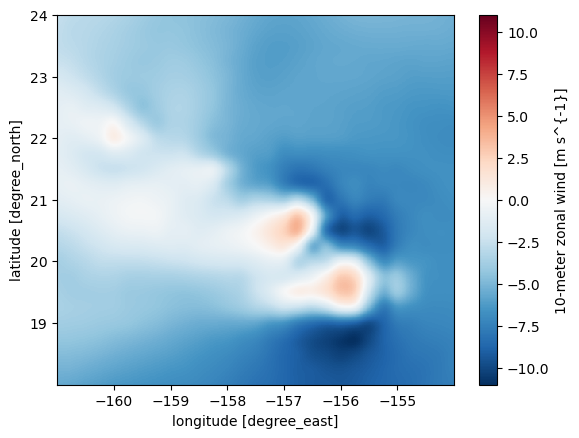

In [24]:
ModelData_NSSL.GetDataTimestep_diag(t=0)['u10'].plot()

In [20]:
climDictionary_NSSL, _ = LoadOrCreateCLims(ModelData_NSSL, varNames)
climDictionary_TEMPO, _ = LoadOrCreateCLims(ModelData_TEMPO, varNames)

File /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/InitialFigures/SurfaceVariableAnimations/climDictionary_Hawaii_TRADES_NSSL.pkl not found. Computing new clim dictionaries.


Processing timesteps:   0%|          | 0/193 [00:00<?, ?it/s]


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
#defining variable names
varNames = [
    "u10", "v10", "q2",
    "hfx", "qfx", "lh",
    "t2m","th2m","cape","cin",
    "rainnc+rainc",
    "refl10cm_1km",
    "greenfrac"]

In [ ]:
#running
for count, t in enumerate(tqdm(num_elements, desc="Processing timesteps")):
    if t % 10 == 0: print(f"Currently working on time {t}/{num_elements[-1]}","\n")
    
    #Loading Data
    [dataSubset_NSSL, dataSubset_diag_NSSL, dataSubset_static_NSSL, lat, lon, _, _] = DataOperator_Class.GetData_Subset(ModelData_NSSL,t)
    [dataSubset_TEMPO, dataSubset_diag_TEMPO, dataSubset_static_TEMPO, _, _, _, _] = DataOperator_Class.GetData_Subset(ModelData_TEMPO,t)

    if (count == 1) and ("greenfrac" in varNames):
        varNames.remove("greenfrac")
    
    # running
    variableDictionary_NSSL = BuildVariableDictionary(ModelData_NSSL, varNames,dataSubset_NSSL,dataSubset_diag_NSSL,dataSubset_static_NSSL,
                                                 lat,lon,climDictionary_NSSL)
    variableDictionary_TEMPO = BuildVariableDictionary(ModelData_TEMPO, varNames,dataSubset_TEMPO,dataSubset_diag_TEMPO,dataSubset_static_TEMPO,
                                                 lat,lon,climDictionary_TEMPO)
    MakePlots(ModelData_NSSL, ModelData_TEMPO,
              variableDictionary_NSSL, variableDictionary_TEMPO, save=True)

In [ ]:
#################
#MAKING ANIMATION
ANIMATE=False #keep false when running with bash code
ANIMATE=True

In [ ]:
if ANIMATE==True:
    #Needed Libraries
    # from matplotlib.animation import FuncAnimation, PillowWriter
    # from PIL import Image
    
    # from moviepy import VideoFileClip, vfx
    
    #Importing AnimationPlotting_Class
    sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis","MPAS_Model_Data"))
    from CLASSES_PlottingModelData import AnimationPlotting_Class

In [ ]:
def GetVariableInputFiles(varName, ModelData1,ModelData2, outputPlottingDirectory):
    folderName = f"{ModelData1.region}_{ModelData1.case}_{ModelData1.mpType}vs{ModelData2.mpType}_{ModelData1.spinup_hours}hrs/{varName}"
    fileName = f"{varName}*.png"
    filePattern = DirectoryManager.GetOutputFile(outputPlottingDirectory, folderName, fileName)
    print(filePattern)
    filePaths = DirectoryManager.GetSortedFileListByTimestamp(filePattern)
    return filePaths

def GetPlottingFileName(varName, ModelData1,ModelData2, outputPlottingDirectory, extension="mp4"):
    folderName = f"{ModelData1.region}_{ModelData1.case}_{ModelData1.mpType}vs{ModelData2.mpType}_{ModelData1.spinup_hours}hrs/{varName}"
    plottingFileName = f"{varName}.{extension}"
    
    plottingFilePath = DirectoryManager.GetOutputFile(outputPlottingDirectory, folderName, plottingFileName)
    return plottingFilePath

In [ ]:
# PNGtoMP4 VERSION
if ANIMATE==True:
    
    # running animation
    fps = AnimationPlotting_Class.CalculateFPS(num_frames=ModelData_NSSL.Ntime, time_interval_minutes=15, desired_duration_min=1)
    for varName in varNames:
        if varName in ["greenfrac"]: continue
        print(f"Working on {varName}","\n")
    
        # Setting up output file
        print("getting file information")
        imageFiles = GetVariableInputFiles(varName, ModelData_NSSL,ModelData_TEMPO, outputPlottingDirectory)
        plottingFilePath = GetPlottingFileName(varName, ModelData_NSSL,ModelData_TEMPO, outputPlottingDirectory)

        print("converting PNGs to MP4")
        if varName in ["q2","qfx","cin","rainnc+rainc","refl10cm_1km"]: #these one's have problems plotting for some reason
            resize=True
        else:
            resize=False
        AnimationPlotting_Class.PNGsToMP4(imageFiles, plottingFilePath, fps=fps)